<a href="https://colab.research.google.com/github/Sathivika/PAPR-Analysis-and-Reduction-Techniques-for-OFDM-Signals-in-LTE-Downlink/blob/main/MWC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

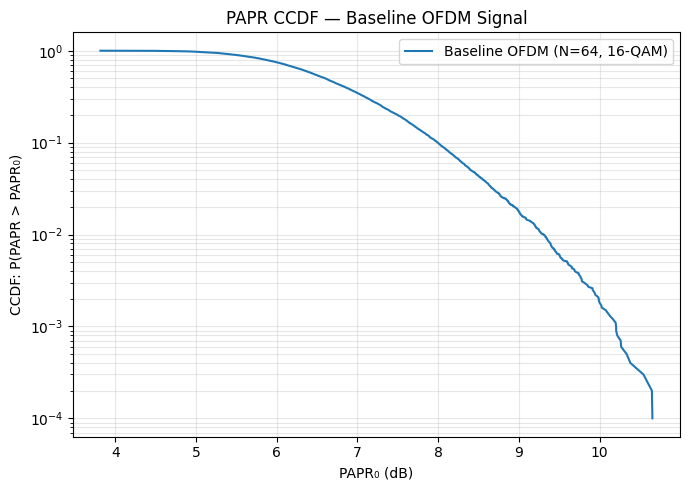

Mean PAPR     : 6.69 dB
Max PAPR      : 10.66 dB
PAPR @ 1% CCDF: 9.30 dB


In [1]:
"""
Step 1: Baseline OFDM signal generation + PAPR measurement
Run this cell-by-cell in Google Colab, or as a standalone script.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------- OFDM Parameters ----------
N = 64               # number of subcarriers
M = 16               # 16-QAM
num_symbols = 10000  # number of OFDM symbols to simulate (for stable PAPR statistics)

# ---------- Step 1a: Generate random 16-QAM symbols ----------
def generate_qam_symbols(num_symbols, N, M):
    """Returns array of shape (num_symbols, N) of unit-average-power 16-QAM symbols."""
    k = int(np.log2(M))              # bits per symbol (4 for 16-QAM)
    half = k // 2
    bits = np.random.randint(0, 2, (num_symbols, N, k))
    levels = np.arange(-np.sqrt(M) + 1, np.sqrt(M), 2)  # e.g. [-3,-1,1,3] for 16-QAM

    def bits_to_pam(bit_group):
        idx = bit_group.dot(1 << np.arange(bit_group.shape[-1])[::-1])
        return levels[idx]

    I = bits_to_pam(bits[:, :, :half])
    Q = bits_to_pam(bits[:, :, half:])
    symbols = I + 1j * Q
    symbols /= np.sqrt((levels ** 2).mean() * 2)  # normalize average power to 1
    return symbols

qam_symbols = generate_qam_symbols(num_symbols, N, M)

# ---------- Step 1b: OFDM modulation (IFFT) ----------
def ofdm_modulate(symbols):
    """IFFT across subcarriers -> time-domain OFDM signal, power-normalized."""
    return np.fft.ifft(symbols, axis=1) * np.sqrt(symbols.shape[1])

ofdm_signal = ofdm_modulate(qam_symbols)

# ---------- Step 1c: Compute PAPR (dB) per OFDM symbol ----------
def compute_papr_db(signal):
    power = np.abs(signal) ** 2
    peak = power.max(axis=1)
    avg = power.mean(axis=1)
    return 10 * np.log10(peak / avg)

papr_db = compute_papr_db(ofdm_signal)

# ---------- Step 1d: CCDF plot ----------
def plot_ccdf(papr_db, label):
    papr_sorted = np.sort(papr_db)
    ccdf = 1 - np.arange(len(papr_sorted)) / len(papr_sorted)
    plt.semilogy(papr_sorted, ccdf, label=label)

plt.figure(figsize=(7, 5))
plot_ccdf(papr_db, f"Baseline OFDM (N={N}, {M}-QAM)")
plt.xlabel("PAPR₀ (dB)")
plt.ylabel("CCDF: P(PAPR > PAPR₀)")
plt.title("PAPR CCDF — Baseline OFDM Signal")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("papr_ccdf_baseline.png", dpi=150)
plt.show()

print(f"Mean PAPR     : {papr_db.mean():.2f} dB")
print(f"Max PAPR      : {papr_db.max():.2f} dB")
print(f"PAPR @ 1% CCDF: {np.percentile(papr_db, 99):.2f} dB")

/tmp/ipykernel_1495/3076193184.py:58: RuntimeWarning: divide by zero encountered in divide
  scale = np.minimum(1.0, threshold / magnitude)


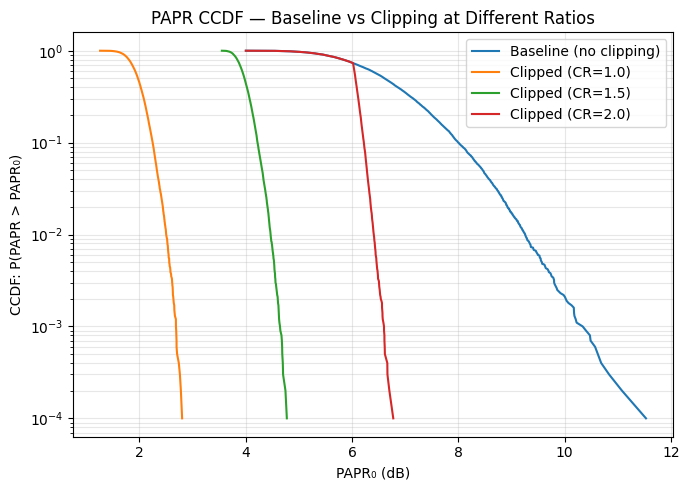

Clip Ratio |  Mean PAPR (dB) |  99% PAPR (dB) |  Distortion EVM (dB)
--------------------------------------------------------------------
  baseline |            6.69 |           9.25 |                    —
       1.0 |            1.98 |           2.50 |               -10.57
       1.5 |            3.99 |           4.47 |               -18.36
       2.0 |            5.97 |           6.41 |               -28.05


In [2]:
"""
Step 2: PAPR reduction via Clipping
Builds on Step 1 — paste this in a NEW Colab cell AFTER running Step 1,
or run standalone (it regenerates the baseline signal itself).
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------- Re-use Step 1 setup (so this cell also runs standalone) ----------
N = 64
M = 16
num_symbols = 10000

def generate_qam_symbols(num_symbols, N, M):
    k = int(np.log2(M))
    half = k // 2
    bits = np.random.randint(0, 2, (num_symbols, N, k))
    levels = np.arange(-np.sqrt(M) + 1, np.sqrt(M), 2)

    def bits_to_pam(bit_group):
        idx = bit_group.dot(1 << np.arange(bit_group.shape[-1])[::-1])
        return levels[idx]

    I = bits_to_pam(bits[:, :, :half])
    Q = bits_to_pam(bits[:, :, half:])
    symbols = I + 1j * Q
    symbols /= np.sqrt((levels ** 2).mean() * 2)
    return symbols

def ofdm_modulate(symbols):
    return np.fft.ifft(symbols, axis=1) * np.sqrt(symbols.shape[1])

def compute_papr_db(signal):
    power = np.abs(signal) ** 2
    peak = power.max(axis=1)
    avg = power.mean(axis=1)
    return 10 * np.log10(peak / avg)

def plot_ccdf(papr_db, label):
    papr_sorted = np.sort(papr_db)
    ccdf = 1 - np.arange(len(papr_sorted)) / len(papr_sorted)
    plt.semilogy(papr_sorted, ccdf, label=label)

qam_symbols = generate_qam_symbols(num_symbols, N, M)
ofdm_signal = ofdm_modulate(qam_symbols)
papr_baseline_db = compute_papr_db(ofdm_signal)

# ---------- Step 2a: Clipping ----------
def clip_signal(signal, clip_ratio):
    """
    Clip amplitude to clip_ratio * RMS, per OFDM symbol.
    clip_ratio = 1.0 means threshold = RMS power level (aggressive clipping).
    """
    rms = np.sqrt(np.mean(np.abs(signal) ** 2, axis=1, keepdims=True))
    threshold = clip_ratio * rms
    magnitude = np.abs(signal)
    scale = np.minimum(1.0, threshold / magnitude)
    return signal * scale

def evm_db(original, distorted):
    """Error Vector Magnitude in dB — proxy for BER degradation from distortion."""
    error_power = np.mean(np.abs(distorted - original) ** 2)
    signal_power = np.mean(np.abs(original) ** 2)
    return 10 * np.log10(error_power / signal_power)

# ---------- Step 2b: Try a few clipping ratios ----------
clip_ratios = [1.0, 1.5, 2.0]
results = {}

plt.figure(figsize=(7, 5))
plot_ccdf(papr_baseline_db, "Baseline (no clipping)")

for cr in clip_ratios:
    clipped_signal = clip_signal(ofdm_signal, cr)
    papr_clipped_db = compute_papr_db(clipped_signal)
    distortion_db = evm_db(ofdm_signal, clipped_signal)
    results[cr] = {
        "mean_papr": papr_clipped_db.mean(),
        "papr_99pct": np.percentile(papr_clipped_db, 99),
        "evm_db": distortion_db,
    }
    plot_ccdf(papr_clipped_db, f"Clipped (CR={cr})")

plt.xlabel("PAPR₀ (dB)")
plt.ylabel("CCDF: P(PAPR > PAPR₀)")
plt.title("PAPR CCDF — Baseline vs Clipping at Different Ratios")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("papr_ccdf_clipping.png", dpi=150)
plt.show()

# ---------- Step 2c: Summary table ----------
print(f"{'Clip Ratio':>10} | {'Mean PAPR (dB)':>15} | {'99% PAPR (dB)':>14} | {'Distortion EVM (dB)':>20}")
print("-" * 68)
print(f"{'baseline':>10} | {papr_baseline_db.mean():>15.2f} | {np.percentile(papr_baseline_db,99):>14.2f} | {'—':>20}")
for cr, r in results.items():
    print(f"{cr:>10} | {r['mean_papr']:>15.2f} | {r['papr_99pct']:>14.2f} | {r['evm_db']:>20.2f}")

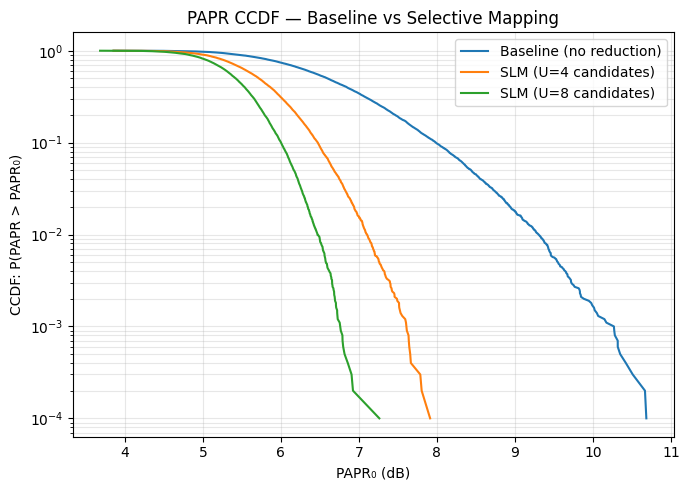

         Technique |  Mean PAPR (dB) |  99% PAPR (dB) |   Side-info overhead
----------------------------------------------------------------------------
          baseline |            6.68 |           9.30 |                 none
         SLM (U=4) |            5.73 |           7.10 |        2 bits/symbol
         SLM (U=8) |            5.41 |           6.47 |        3 bits/symbol


In [3]:
"""
Step 3: PAPR reduction via Selective Mapping (SLM)
Paste in a NEW Colab cell after Steps 1 & 2 (or run standalone).
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------- Re-use setup ----------
N = 64
M = 16
num_symbols = 10000
rng = np.random.default_rng(42)

def generate_qam_symbols(num_symbols, N, M):
    k = int(np.log2(M))
    half = k // 2
    bits = np.random.randint(0, 2, (num_symbols, N, k))
    levels = np.arange(-np.sqrt(M) + 1, np.sqrt(M), 2)

    def bits_to_pam(bit_group):
        idx = bit_group.dot(1 << np.arange(bit_group.shape[-1])[::-1])
        return levels[idx]

    I = bits_to_pam(bits[:, :, :half])
    Q = bits_to_pam(bits[:, :, half:])
    symbols = I + 1j * Q
    symbols /= np.sqrt((levels ** 2).mean() * 2)
    return symbols

def ofdm_modulate(symbols):
    return np.fft.ifft(symbols, axis=1) * np.sqrt(symbols.shape[1])

def compute_papr_db(signal):
    power = np.abs(signal) ** 2
    peak = power.max(axis=1)
    avg = power.mean(axis=1)
    return 10 * np.log10(peak / avg)

def plot_ccdf(papr_db, label):
    papr_sorted = np.sort(papr_db)
    ccdf = 1 - np.arange(len(papr_sorted)) / len(papr_sorted)
    plt.semilogy(papr_sorted, ccdf, label=label)

qam_symbols = generate_qam_symbols(num_symbols, N, M)
ofdm_signal = ofdm_modulate(qam_symbols)
papr_baseline_db = compute_papr_db(ofdm_signal)

# ---------- Step 3a: SLM ----------
def generate_phase_vectors(U, N, rng):
    """U candidate phase-rotation vectors, each of length N. First one = identity (no rotation)."""
    vectors = np.ones((U, N), dtype=complex)
    for u in range(1, U):
        vectors[u] = np.exp(1j * 2 * np.pi * rng.random(N))
    return vectors

def apply_slm(qam_symbols, U, rng):
    """For each OFDM symbol, build U phase-rotated candidates and keep the lowest-PAPR one."""
    N = qam_symbols.shape[1]
    phase_vectors = generate_phase_vectors(U, N, rng)          # (U, N)
    candidates_freq = qam_symbols[None, :, :] * phase_vectors[:, None, :]   # (U, num_symbols, N)
    candidates_time = np.fft.ifft(candidates_freq, axis=2) * np.sqrt(N)
    power = np.abs(candidates_time) ** 2
    papr_db_matrix = 10 * np.log10(power.max(axis=2) / power.mean(axis=2))  # (U, num_symbols)
    best_papr_db = papr_db_matrix.min(axis=0)
    best_u = papr_db_matrix.argmin(axis=0)
    return best_papr_db, best_u

papr_slm4_db, _ = apply_slm(qam_symbols, U=4, rng=rng)
papr_slm8_db, _ = apply_slm(qam_symbols, U=8, rng=rng)

# ---------- Step 3b: Plot comparison ----------
plt.figure(figsize=(7, 5))
plot_ccdf(papr_baseline_db, "Baseline (no reduction)")
plot_ccdf(papr_slm4_db, "SLM (U=4 candidates)")
plot_ccdf(papr_slm8_db, "SLM (U=8 candidates)")
plt.xlabel("PAPR₀ (dB)")
plt.ylabel("CCDF: P(PAPR > PAPR₀)")
plt.title("PAPR CCDF — Baseline vs Selective Mapping")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("papr_ccdf_slm.png", dpi=150)
plt.show()

# ---------- Step 3c: Summary table ----------
print(f"{'Technique':>18} | {'Mean PAPR (dB)':>15} | {'99% PAPR (dB)':>14} | {'Side-info overhead':>20}")
print("-" * 76)
print(f"{'baseline':>18} | {papr_baseline_db.mean():>15.2f} | {np.percentile(papr_baseline_db,99):>14.2f} | {'none':>20}")
print(f"{'SLM (U=4)':>18} | {papr_slm4_db.mean():>15.2f} | {np.percentile(papr_slm4_db,99):>14.2f} | {'2 bits/symbol':>20}")
print(f"{'SLM (U=8)':>18} | {papr_slm8_db.mean():>15.2f} | {np.percentile(papr_slm8_db,99):>14.2f} | {'3 bits/symbol':>20}")

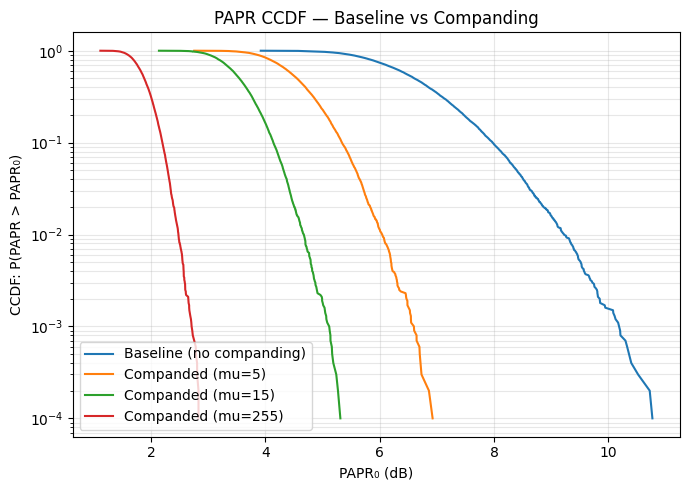

             Technique |  Mean PAPR (dB) |  99% PAPR (dB)
----------------------------------------------------------
              baseline |            6.68 |           9.22
        companded mu=5 |            4.58 |           6.04
       companded mu=15 |            3.56 |           4.67
      companded mu=255 |            1.89 |           2.48

--- Noise-enhancement cost (fixed channel noise, mu=15) ---
EVM WITHOUT companding : -27.45 dB
EVM WITH companding    : -29.93 dB   (higher = more noise damage)


In [4]:
"""
Step 4: PAPR reduction via Companding (mu-law)
Paste in a NEW Colab cell after Steps 1-3 (or run standalone).
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------- Re-use setup ----------
N = 64
M = 16
num_symbols = 10000
rng = np.random.default_rng(42)

def generate_qam_symbols(num_symbols, N, M):
    k = int(np.log2(M))
    half = k // 2
    bits = np.random.randint(0, 2, (num_symbols, N, k))
    levels = np.arange(-np.sqrt(M) + 1, np.sqrt(M), 2)

    def bits_to_pam(bit_group):
        idx = bit_group.dot(1 << np.arange(bit_group.shape[-1])[::-1])
        return levels[idx]

    I = bits_to_pam(bits[:, :, :half])
    Q = bits_to_pam(bits[:, :, half:])
    symbols = I + 1j * Q
    symbols /= np.sqrt((levels ** 2).mean() * 2)
    return symbols

def ofdm_modulate(symbols):
    return np.fft.ifft(symbols, axis=1) * np.sqrt(symbols.shape[1])

def compute_papr_db(signal):
    power = np.abs(signal) ** 2
    peak = power.max(axis=1)
    avg = power.mean(axis=1)
    return 10 * np.log10(peak / avg)

def plot_ccdf(papr_db, label):
    papr_sorted = np.sort(papr_db)
    ccdf = 1 - np.arange(len(papr_sorted)) / len(papr_sorted)
    plt.semilogy(papr_sorted, ccdf, label=label)

qam_symbols = generate_qam_symbols(num_symbols, N, M)
ofdm_signal = ofdm_modulate(qam_symbols)
papr_baseline_db = compute_papr_db(ofdm_signal)
A_max = np.max(np.abs(ofdm_signal))   # global peak reference for the companding law

# ---------- Step 4a: mu-law compand / expand ----------
def compand_mu_law(signal, mu, A_max):
    """Compress amplitude nonlinearly; keeps phase unchanged."""
    amplitude = np.abs(signal)
    phase = np.angle(signal)
    companded_amp = A_max * np.log1p(mu * amplitude / A_max) / np.log1p(mu)
    return companded_amp * np.exp(1j * phase)

def expand_mu_law(signal, mu, A_max):
    """Inverse of compand_mu_law — applied at the receiver."""
    amplitude = np.abs(signal)
    phase = np.angle(signal)
    expanded_amp = (A_max / mu) * np.expm1(amplitude / A_max * np.log1p(mu))
    return expanded_amp * np.exp(1j * phase)

def evm_db(original, distorted):
    error_power = np.mean(np.abs(distorted - original) ** 2)
    signal_power = np.mean(np.abs(original) ** 2)
    return 10 * np.log10(error_power / signal_power)

# ---------- Step 4b: PAPR reduction from companding ----------
mu_values = [5, 15, 255]
papr_results = {}
plt.figure(figsize=(7, 5))
plot_ccdf(papr_baseline_db, "Baseline (no companding)")

for mu in mu_values:
    companded = compand_mu_law(ofdm_signal, mu, A_max)
    papr_companded_db = compute_papr_db(companded)
    papr_results[mu] = papr_companded_db
    plot_ccdf(papr_companded_db, f"Companded (mu={mu})")

plt.xlabel("PAPR₀ (dB)")
plt.ylabel("CCDF: P(PAPR > PAPR₀)")
plt.title("PAPR CCDF — Baseline vs Companding")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("papr_ccdf_companding.png", dpi=150)
plt.show()

# ---------- Step 4c: Noise-enhancement cost (the real trade-off) ----------
noise_std = 0.03  # fixed channel noise level, same for every comparison below
noise = (rng.normal(0, noise_std, ofdm_signal.shape) +
         1j * rng.normal(0, noise_std, ofdm_signal.shape))

# (i) No companding: noise added directly
noisy_plain = ofdm_signal + noise
evm_plain_db = evm_db(ofdm_signal, noisy_plain)

# (ii) With companding: noise added AFTER companding, then expanded back
mu_test = 15
companded = compand_mu_law(ofdm_signal, mu_test, A_max)
noisy_companded = companded + noise
recovered = expand_mu_law(noisy_companded, mu_test, A_max)
evm_companded_db = evm_db(ofdm_signal, recovered)

print(f"{'Technique':>22} | {'Mean PAPR (dB)':>15} | {'99% PAPR (dB)':>14}")
print("-" * 58)
print(f"{'baseline':>22} | {papr_baseline_db.mean():>15.2f} | {np.percentile(papr_baseline_db,99):>14.2f}")
for mu in mu_values:
    p = papr_results[mu]
    print(f"{'companded mu='+str(mu):>22} | {p.mean():>15.2f} | {np.percentile(p,99):>14.2f}")

print("\n--- Noise-enhancement cost (fixed channel noise, mu=15) ---")
print(f"EVM WITHOUT companding : {evm_plain_db:.2f} dB")
print(f"EVM WITH companding    : {evm_companded_db:.2f} dB   (higher = more noise damage)")

/tmp/ipykernel_1495/1563708351.py:50: RuntimeWarning: divide by zero encountered in divide
  scale = np.minimum(1.0, threshold / magnitude)


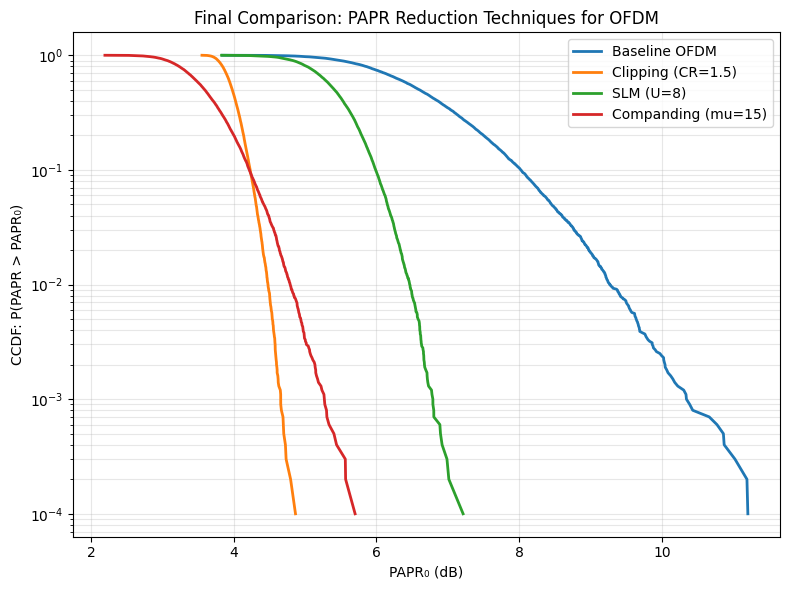

Technique              |   Mean PAPR |    99% PAPR |   Reduction | Primary trade-off
----------------------------------------------------------------------------------------------------
Baseline               |     6.69 dB |     9.27 dB |      0.00 dB | none
Clipping (CR=1.5)      |     4.00 dB |     4.48 dB |      2.69 dB | Signal distortion (EVM)
SLM (U=8)              |     5.41 dB |     6.46 dB |      1.28 dB | Side info (3 bits/symbol) + 8x IFFT cost
Companding (mu=15)     |     3.62 dB |     4.79 dB |      3.07 dB | Altered noise sensitivity profile


In [5]:
"""
Step 5: Final combined comparison - Baseline vs Clipping vs SLM vs Companding
Paste as the LAST cell in your Colab notebook, after Steps 1-4.
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------- Setup ----------
N = 64
M = 16
num_symbols = 10000
rng = np.random.default_rng(42)

def generate_qam_symbols(num_symbols, N, M):
    k = int(np.log2(M))
    half = k // 2
    bits = np.random.randint(0, 2, (num_symbols, N, k))
    levels = np.arange(-np.sqrt(M) + 1, np.sqrt(M), 2)
    def bits_to_pam(bit_group):
        idx = bit_group.dot(1 << np.arange(bit_group.shape[-1])[::-1])
        return levels[idx]
    I = bits_to_pam(bits[:, :, :half])
    Q = bits_to_pam(bits[:, :, half:])
    symbols = I + 1j * Q
    symbols /= np.sqrt((levels ** 2).mean() * 2)
    return symbols

def ofdm_modulate(symbols):
    return np.fft.ifft(symbols, axis=1) * np.sqrt(symbols.shape[1])

def compute_papr_db(signal):
    power = np.abs(signal) ** 2
    return 10 * np.log10(power.max(axis=1) / power.mean(axis=1))

def plot_ccdf(papr_db, label):
    papr_sorted = np.sort(papr_db)
    ccdf = 1 - np.arange(len(papr_sorted)) / len(papr_sorted)
    plt.semilogy(papr_sorted, ccdf, label=label, linewidth=2)

qam_symbols = generate_qam_symbols(num_symbols, N, M)
ofdm_signal = ofdm_modulate(qam_symbols)
papr_baseline_db = compute_papr_db(ofdm_signal)

# ---------- Clipping (CR = 1.5) ----------
def clip_signal(signal, clip_ratio):
    rms = np.sqrt(np.mean(np.abs(signal) ** 2, axis=1, keepdims=True))
    threshold = clip_ratio * rms
    magnitude = np.abs(signal)
    scale = np.minimum(1.0, threshold / magnitude)
    return signal * scale

clipped_signal = clip_signal(ofdm_signal, clip_ratio=1.5)
papr_clip_db = compute_papr_db(clipped_signal)

# ---------- SLM (U = 8) ----------
def generate_phase_vectors(U, N, rng):
    vectors = np.ones((U, N), dtype=complex)
    for u in range(1, U):
        vectors[u] = np.exp(1j * 2 * np.pi * rng.random(N))
    return vectors

def apply_slm(symbols, U, rng):
    N = symbols.shape[1]
    phase_vectors = generate_phase_vectors(U, N, rng)
    candidates_freq = symbols[None, :, :] * phase_vectors[:, None, :]
    candidates_time = np.fft.ifft(candidates_freq, axis=2) * np.sqrt(N)
    power = np.abs(candidates_time) ** 2
    papr_matrix = 10 * np.log10(power.max(axis=2) / power.mean(axis=2))
    return papr_matrix.min(axis=0)

papr_slm_db = apply_slm(qam_symbols, U=8, rng=rng)

# ---------- Companding (mu = 15) ----------
def compand_mu_law(signal, mu, A_max):
    amplitude = np.abs(signal)
    phase = np.angle(signal)
    companded_amp = A_max * np.log1p(mu * amplitude / A_max) / np.log1p(mu)
    return companded_amp * np.exp(1j * phase)

A_max = np.max(np.abs(ofdm_signal))
companded_signal = compand_mu_law(ofdm_signal, mu=15, A_max=A_max)
papr_compand_db = compute_papr_db(companded_signal)

# ---------- Final combined CCDF plot ----------
plt.figure(figsize=(8, 6))
plot_ccdf(papr_baseline_db, "Baseline OFDM")
plot_ccdf(papr_clip_db, "Clipping (CR=1.5)")
plot_ccdf(papr_slm_db, "SLM (U=8)")
plot_ccdf(papr_compand_db, "Companding (mu=15)")
plt.xlabel("PAPR₀ (dB)")
plt.ylabel("CCDF: P(PAPR > PAPR₀)")
plt.title("Final Comparison: PAPR Reduction Techniques for OFDM")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("papr_final_comparison.png", dpi=150)
plt.show()

# ---------- Final summary table ----------
def summary_row(name, papr_db, note):
    reduction = papr_baseline_db.mean() - papr_db.mean()
    print(f"{name:<22} | {papr_db.mean():>8.2f} dB | {np.percentile(papr_db,99):>8.2f} dB | "
          f"{reduction:>9.2f} dB | {note}")

print(f"{'Technique':<22} | {'Mean PAPR':>11} | {'99% PAPR':>11} | {'Reduction':>11} | Primary trade-off")
print("-" * 100)
summary_row("Baseline", papr_baseline_db, "none")
summary_row("Clipping (CR=1.5)", papr_clip_db, "Signal distortion (EVM)")
summary_row("SLM (U=8)", papr_slm_db, "Side info (3 bits/symbol) + 8x IFFT cost")
summary_row("Companding (mu=15)", papr_compand_db, "Altered noise sensitivity profile")